In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

from energy_thief.envs import GridThiefEnvL2, ACTION_NAMES_L2
from energy_thief.agents import QLearningAgent

rng = np.random.default_rng(0)
plt.rcParams["figure.dpi"] = 110

In [2]:
env = GridThiefEnvL2(seed=1)
print(f"states: {env.n_states}   actions: {env.n_actions}")
print(f"consumers: {env.consumers}")
for s in range(env.n_substations):
    members = [env.consumers[i] for i in range(env.n_consumers) if env.substation_of[i] == s]
    print(f"  {env.substations[s]} (monitoring x{env.substation_sens[s]:g}): {members}")
print(f"suspicion levels k = {env.k}  (risk x (1 + {env.susp_factor:g}*sigma)),  cool prob = {env.cool_prob}")
print(f"|S| = n_phase x (U_max+1) x k^n = {env.n_phase} x {env.surplus_max+1} x {env.k}^{env.n_consumers} = {env.n_states}")
print(env.render())

states: 26244   actions: 13
consumers: ('C1', 'C2', 'C3', 'C4', 'C5', 'C6')
  S1 (monitoring x1): ['C1', 'C2', 'C3']
  S2 (monitoring x1.3): ['C4', 'C5', 'C6']
suspicion levels k = 3  (risk x (1 + 1*sigma)),  cool prob = 0.3
|S| = n_phase x (U_max+1) x k^n = 4 x 9 x 3^6 = 26244
t=0   phase=0 surplus=0/8  heat[C10 C20 C30 C40 C50 C60]  [S1:C1C2C3  S2:C4C5C6]


## The environment at a glance

**Left:** the network — a plant feeds **two substations**, each serving three
consumers; **S2 is monitored more closely** ($\times 1.3$), so its consumers are
riskier to tap. **Middle:** the divertible **slack** on each edge per demand phase
(where it is safe to redirect flow), labelled by substation. **Right:** the Level-2
twist — for an **overdraw**, suspicion multiplies the alarm probability by
$(1+\beta_\sigma\sigma)$ (shown for an S1 edge; $\times 1.3$ again for S2), so an edge
tapped repeatedly becomes almost certain to trip the alarm, pushing the thief to
spread its taps across the grid.

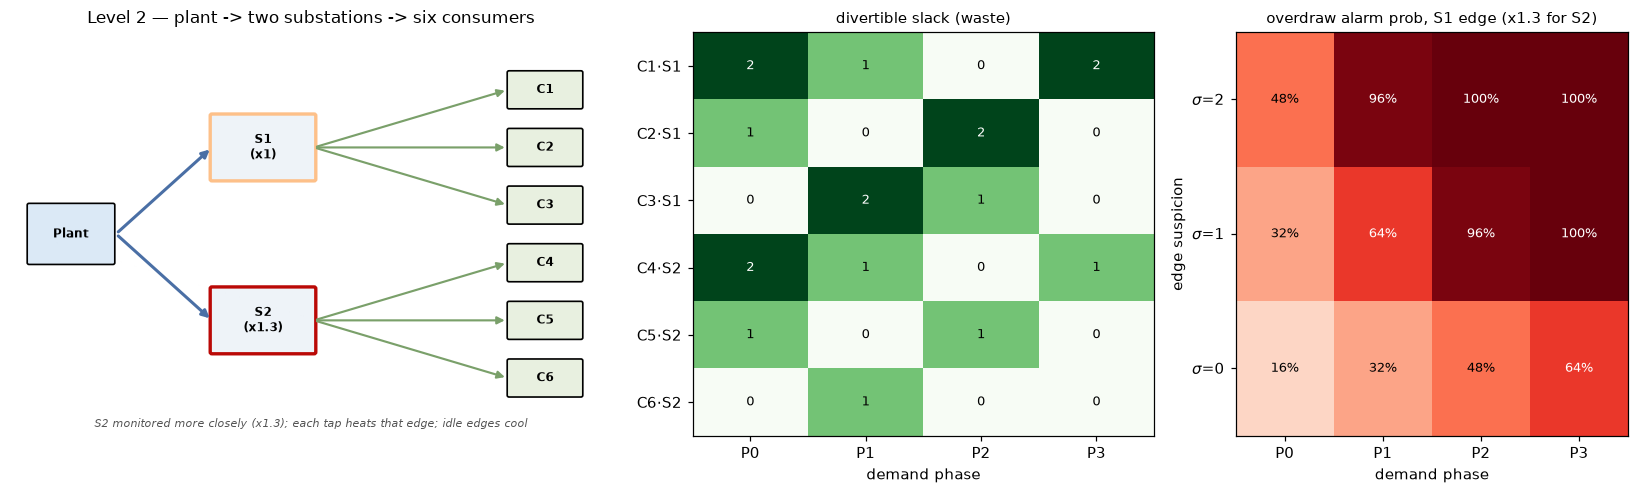

In [3]:
fig, (axS, axK, axH) = plt.subplots(1, 3, figsize=(15, 4.6),
                                    gridspec_kw={"width_ratios": [1.3, 1, 0.85]})
n = env.n_consumers

# Panel 1: network schematic with two substations
axS.set_xlim(0, 10); axS.set_ylim(0, n + 1.0); axS.axis("off")
def box(x, y, w, h, label, fc, ec="black", lw=1.1):
    axS.add_patch(FancyBboxPatch((x - w/2, y - h/2), w, h, boxstyle="round,pad=0.03",
                  fc=fc, ec=ec, lw=lw))
    axS.text(x, y, label, ha="center", va="center", fontsize=8, weight="bold")
cons_y = {i: n - i for i in range(n)}
ymid = (n + 1.0) / 2
box(1.0, ymid, 1.4, 1.0, "Plant", "#dbe9f6")
sub_cmap = plt.get_cmap("OrRd"); maxf = max(env.substation_sens)
for s in range(env.n_substations):
    members = [i for i in range(n) if env.substation_of[i] == s]
    sy = float(np.mean([cons_y[i] for i in members])); factor = env.substation_sens[s]
    ec = sub_cmap(0.35 + 0.5 * (factor - 1.0) / max(1e-9, maxf - 1.0))
    box(4.2, sy, 1.7, 1.1, f"{env.substations[s]}\n(x{factor:g})", "#eef3f8", ec=ec, lw=2.2)
    axS.annotate("", xy=(3.35, sy), xytext=(1.75, ymid),
                 arrowprops=dict(arrowstyle="-|>", lw=2.0, color="#4a6fa5"))
    for i in members:
        box(8.9, cons_y[i], 1.2, 0.6, env.consumers[i], "#e8f0e0")
        axS.annotate("", xy=(8.28, cons_y[i]), xytext=(5.05, sy),
                     arrowprops=dict(arrowstyle="-|>", lw=1.4, color="#7aa06a"))
axS.set_title("Level 2 — plant -> two substations -> six consumers", fontsize=11)
axS.text(5.0, 0.15, "S2 monitored more closely (x1.3); each tap heats that edge; idle edges cool",
         ha="center", fontsize=7.5, style="italic", color="#555")

# Panel 2: slack per (consumer x phase), labelled by substation
axK.imshow(env.slack.T, cmap="Greens", aspect="auto", vmin=0, vmax=env.slack.max())
for i in range(n):
    for ph in range(env.n_phase):
        axK.text(ph, i, str(env.slack[ph, i]), ha="center", va="center", fontsize=8.5,
                 color="white" if env.slack[ph, i] > env.slack.max()*0.6 else "black")
axK.set_xticks(range(env.n_phase)); axK.set_xticklabels([f"P{p}" for p in range(env.n_phase)])
axK.set_yticks(range(n))
axK.set_yticklabels([f"{env.consumers[i]}·{env.substations[env.substation_of[i]]}" for i in range(n)])
axK.set_xlabel("demand phase"); axK.set_title("divertible slack (waste)", fontsize=10)

# Panel 3: suspicion inflates overdraw risk (sigma x phase) for an S1 edge
sus_risk = np.array([[min(1.0, env.sens[ph] * (env.base_divert + env.shortfall_weight * env.overdraw_extra)
                          * (1 + env.susp_factor * s)) for ph in range(env.n_phase)]
                     for s in range(env.k)])
axH.imshow(sus_risk, cmap="Reds", aspect="auto", vmin=0, vmax=1, origin="lower")
for s in range(env.k):
    for ph in range(env.n_phase):
        axH.text(ph, s, f"{sus_risk[s, ph]*100:.0f}%", ha="center", va="center", fontsize=8.5,
                 color="white" if sus_risk[s, ph] > 0.5 else "black")
axH.set_xticks(range(env.n_phase)); axH.set_xticklabels([f"P{p}" for p in range(env.n_phase)])
axH.set_yticks(range(env.k)); axH.set_yticklabels([f"$\\sigma$={s}" for s in range(env.k)])
axH.set_xlabel("demand phase"); axH.set_ylabel("edge suspicion")
axH.set_title("overdraw alarm prob, S1 edge (x1.3 for S2)", fontsize=10)
fig.tight_layout(); plt.show()

In [4]:
def evaluate(env, agent, n_episodes=1000):
    rets = np.empty(n_episodes)
    for ep in range(n_episodes):
        s, _ = env.reset()
        done, g = False, 0.0
        while not done:
            a = agent.select_action(s, greedy=True)
            s, r, term, trunc, _ = env.step(a)
            g, done = g + r, term or trunc
        rets[ep] = g
    return rets.mean(), rets.std()


def train(env, n_episodes, seed, eval_env=None, eval_every=250, eval_episodes=50, **kw):
    agent = QLearningAgent(env.n_states, env.action_space.n, seed=seed, **kw)
    returns = np.empty(n_episodes)
    epsilons = np.empty(n_episodes)
    eval_x, eval_y = [], []
    visited = set()
    for ep in range(n_episodes):
        s, _ = env.reset()
        done, g = False, 0.0
        while not done:
            visited.add(s)
            a = agent.select_action(s)
            s2, r, term, trunc, _ = env.step(a)
            agent.update(s, a, r, s2, term)
            s, g, done = s2, g + r, term or trunc
        returns[ep] = g
        epsilons[ep] = agent.epsilon
        agent.end_episode()
        if eval_env is not None and (ep + 1) % eval_every == 0:
            m, _ = evaluate(eval_env, agent, eval_episodes)
            eval_x.append(ep + 1); eval_y.append(m)
    return agent, returns, np.array(eval_x), np.array(eval_y), epsilons, len(visited)

In [5]:
N_EPISODES = 8000
SEEDS = range(5)
HP = dict(alpha=0.1, gamma=0.99, epsilon_decay=0.9995)

curves, eval_curves, agents, coverage = [], [], [], []
eval_x, epsilons = None, None
for seed in SEEDS:
    agent, returns, ex, ey, eps, nvis = train(
        GridThiefEnvL2(seed=1), N_EPISODES, seed=seed, eval_env=GridThiefEnvL2(seed=1), **HP)
    curves.append(returns); eval_curves.append(ey); agents.append(agent); coverage.append(nvis)
    eval_x = ex
    epsilons = eps if epsilons is None else epsilons
curves = np.array(curves); eval_curves = np.array(eval_curves)
print("training done:", curves.shape)

training done: (5, 8000)


## Learning curve

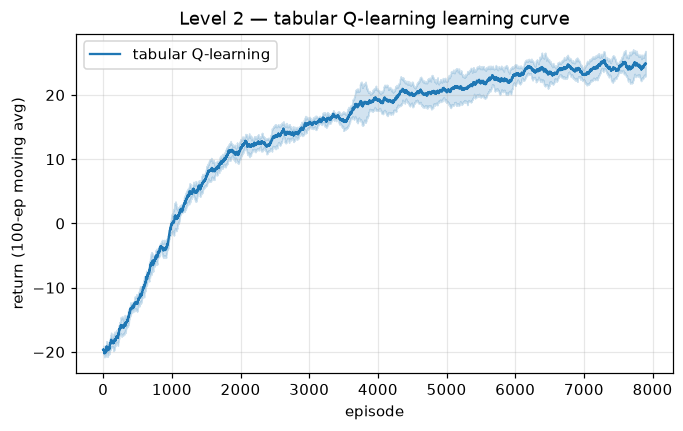

In [6]:
def moving_average(x, w=100):
    return np.convolve(x, np.ones(w) / w, mode="valid")

smoothed = np.array([moving_average(c) for c in curves])
mean, std = smoothed.mean(0), smoothed.std(0)
x = np.arange(smoothed.shape[1])
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, mean, color="C0", label="tabular Q-learning")
ax.fill_between(x, mean - std, mean + std, color="C0", alpha=0.2)
ax.set_xlabel("episode"); ax.set_ylabel("return (100-ep moving avg)")
ax.set_title("Level 2 — tabular Q-learning learning curve")
ax.legend(); ax.grid(alpha=0.3); plt.show()

## Greedy evaluation return

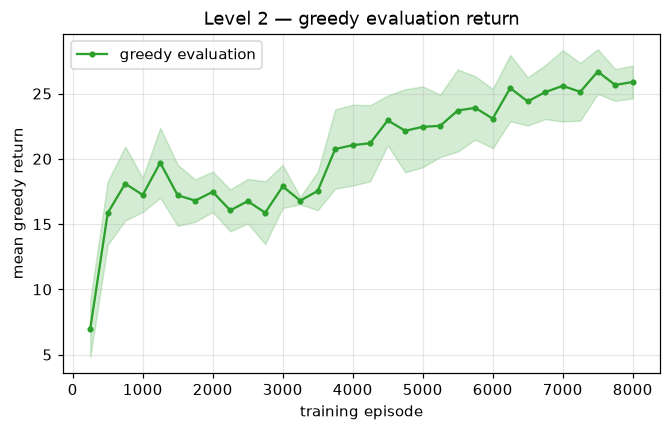

final greedy return: +25.89 ± 1.25


In [7]:
ev_mean, ev_std = eval_curves.mean(0), eval_curves.std(0)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(eval_x, ev_mean, color="C2", marker="o", ms=3, label="greedy evaluation")
ax.fill_between(eval_x, ev_mean - ev_std, ev_mean + ev_std, color="C2", alpha=0.2)
ax.set_xlabel("training episode"); ax.set_ylabel("mean greedy return")
ax.set_title("Level 2 — greedy evaluation return")
ax.legend(); ax.grid(alpha=0.3); plt.show()
print(f"final greedy return: {ev_mean[-1]:+.2f} ± {ev_std[-1]:.2f}")

## Exploration schedule

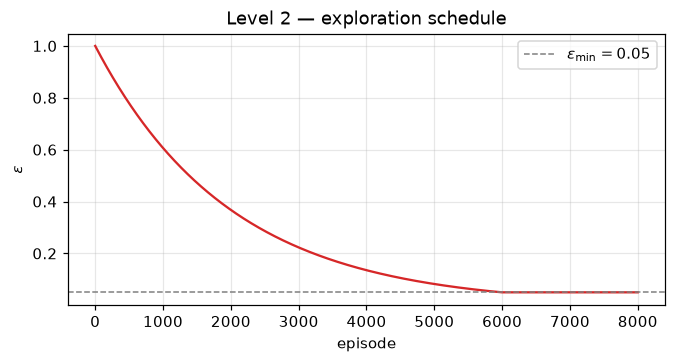

In [8]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(np.arange(len(epsilons)), epsilons, color="C3")
ax.axhline(agents[0].epsilon_min, ls="--", color="grey", lw=1,
           label=fr"$\varepsilon_{{\min}} = {agents[0].epsilon_min}$")
ax.set_xlabel("episode"); ax.set_ylabel(r"$\varepsilon$")
ax.set_title("Level 2 — exploration schedule")
ax.legend(); ax.grid(alpha=0.3); plt.show()

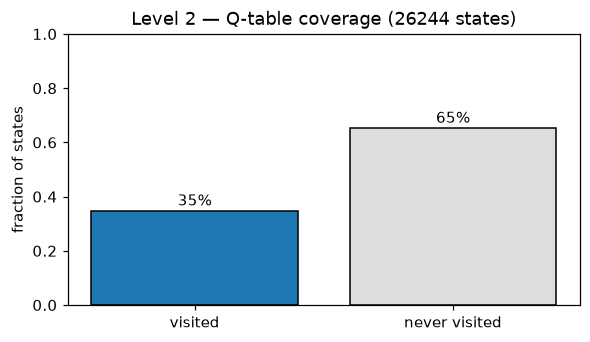

states visited: 9120 / 26244 = 34.7% (mean over seeds)


In [9]:
cov = np.array(coverage); frac = cov / env.n_states
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.bar(["visited", "never visited"], [frac.mean(), 1 - frac.mean()],
       color=["C0", "#ddd"], edgecolor="black")
ax.set_ylabel("fraction of states"); ax.set_ylim(0, 1)
ax.set_title(f"Level 2 — Q-table coverage ({env.n_states} states)")
for i, v in enumerate([frac.mean(), 1 - frac.mean()]):
    ax.text(i, v + 0.02, f"{v:.0%}", ha="center")
plt.show()
print(f"states visited: {cov.mean():.0f} / {env.n_states} = {frac.mean():.1%} (mean over seeds)")

## The learned policy (a slice)

The full state is high-dimensional, so we show the slice with **all edges cold**
($\sigma=0$): the greedy action over $(\text{phase}, \text{surplus})$. At low surplus
the thief skims the high-slack edge for the phase; it secures as surplus and grid
tightness rise. The **high-surplus, all-cold corner** (right) is rarely reached — you
build surplus *by* tapping, which raises suspicion — so those cells are under-visited
and their action is a noisy estimate, itself a symptom of the coverage gap above.

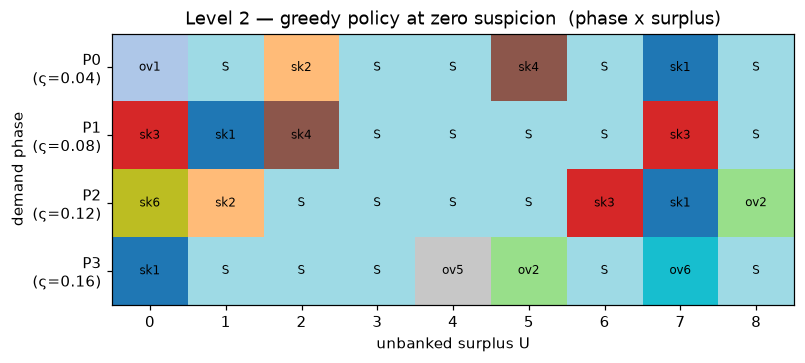

In [10]:
KE = env.k ** env.n_consumers
def obs_zero_susp(P, U):
    return (P * (env.surplus_max + 1) + U) * KE
def short(a):
    if a == env.SECURE: return "S"
    c, ov = divmod(a, 2)
    return f"{'ov' if ov else 'sk'}{c+1}"

policy = np.array([[int(agents[0].Q[obs_zero_susp(P, U)].argmax())
                    for U in range(env.surplus_max + 1)] for P in range(env.n_phase)])
cmap = plt.get_cmap("tab20", env.n_actions)
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.imshow(policy, cmap=cmap, vmin=0, vmax=env.n_actions - 1, aspect="auto")
for P in range(env.n_phase):
    for U in range(env.surplus_max + 1):
        ax.text(U, P, short(policy[P, U]), ha="center", va="center", fontsize=8)
ax.set_xticks(range(env.surplus_max + 1)); ax.set_yticks(range(env.n_phase))
ax.set_yticklabels([f"P{P}\n(ς={env.sens[P]:.2f})" for P in range(env.n_phase)])
ax.set_xlabel("unbanked surplus U"); ax.set_ylabel("demand phase")
ax.set_title("Level 2 — greedy policy at zero suspicion  (phase x surplus)")
plt.show()

## A single shift, step by step

One greedy episode. Top: the demand phase. Middle: the surplus (secures $\vee$, alarms
$\times$). Bottom: the **suspicion of every edge over time** — the Level-2 signature.
Watch the thief **rotate across edges** so none stays hot: that diversification keeps
its alarm risk manageable.

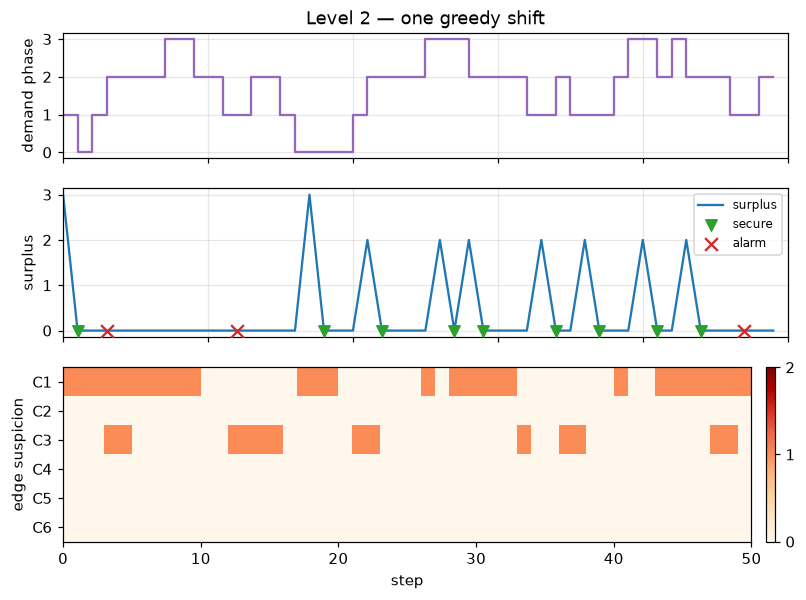

In [11]:
def greedy_trace(env, agent):
    s, _ = env.reset()
    phases, surplus, secures, alarms, susp_hist = [], [], [], [], []
    done, t = False, 0
    while not done:
        a = agent.select_action(s, greedy=True)
        s, r, term, trunc, info = env.step(a)
        phases.append(info["phase"]); surplus.append(info["surplus"])
        susp_hist.append(info["suspicion"])
        if info["banked"] > 0: secures.append(t)
        if info["alarm"]: alarms.append(t)
        done, t = term or trunc, t + 1
    return np.array(phases), np.array(surplus), np.array(susp_hist).T, secures, alarms

phases, surplus, susp_hist, secures, alarms = greedy_trace(GridThiefEnvL2(seed=7), agents[0])
steps = np.arange(len(phases))

fig, (a1, a2, a3) = plt.subplots(3, 1, figsize=(8.5, 6), sharex=True,
                                 gridspec_kw={"height_ratios": [1, 1.2, 1.4]})
a1.step(steps, phases, where="post", color="C4"); a1.set_ylabel("demand phase")
a1.set_yticks(range(env.n_phase)); a1.grid(alpha=0.3)
a1.set_title("Level 2 — one greedy shift")

a2.plot(steps, surplus, color="C0", label="surplus")
a2.scatter(secures, surplus[secures], marker="v", color="C2", s=55, zorder=3, label="secure")
if alarms:
    a2.scatter(alarms, np.zeros(len(alarms)), marker="x", color="C3", s=70, zorder=3, label="alarm")
a2.set_ylabel("surplus"); a2.grid(alpha=0.3); a2.legend(loc="upper right", fontsize=8)

im = a3.imshow(susp_hist, cmap="OrRd", aspect="auto", vmin=0, vmax=env.k - 1,
               extent=[0, len(phases), env.n_consumers - 0.5, -0.5])
a3.set_yticks(range(env.n_consumers)); a3.set_yticklabels(env.consumers)
a3.set_ylabel("edge suspicion"); a3.set_xlabel("step")
fig.colorbar(im, ax=a3, fraction=0.03, pad=0.02, ticks=range(env.k))
plt.show()